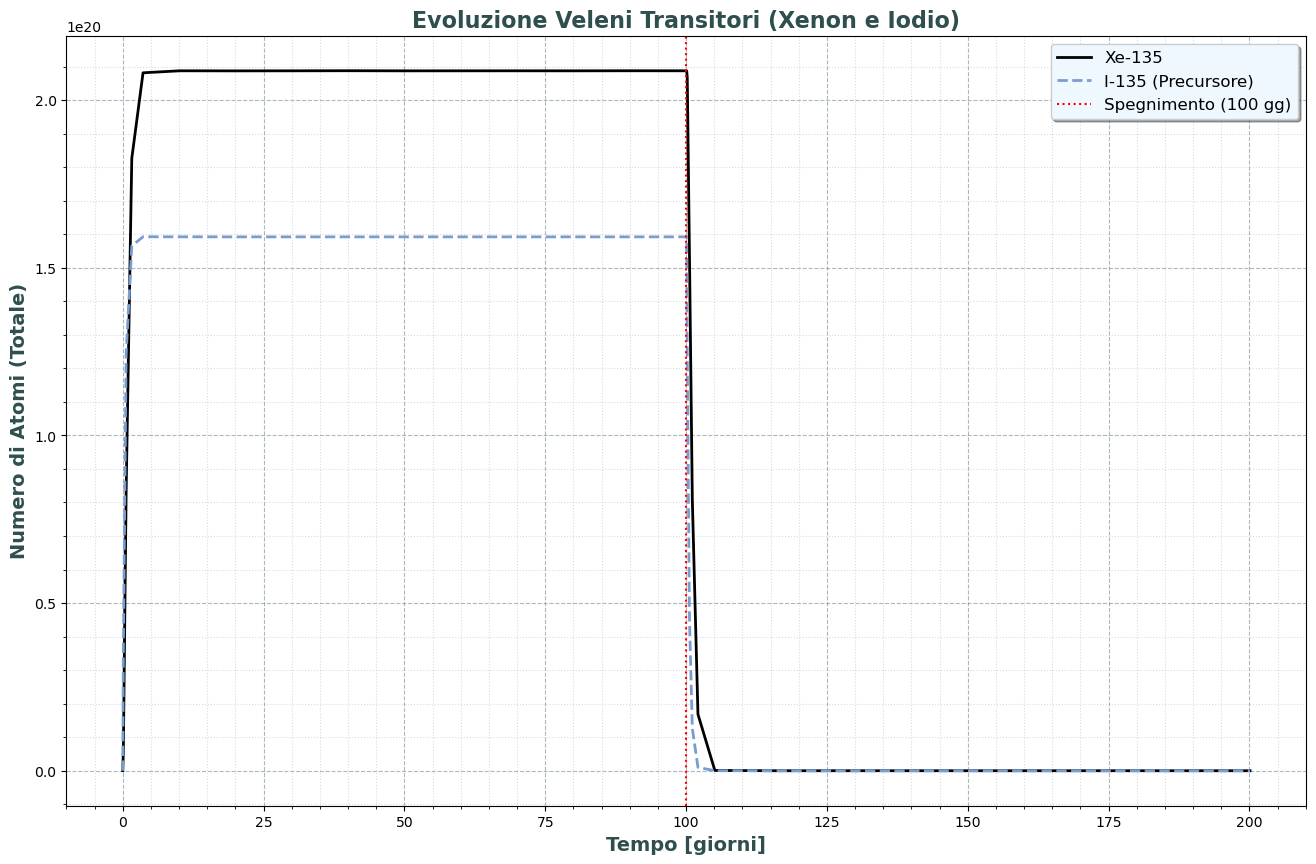

In [1]:
import openmc.deplete
import matplotlib.pyplot as plt
import numpy as np

# 1. Caricamento dei risultati dal file HDF5
results = openmc.deplete.Results("depletion_results.h5")

# 2. Estrazione vettori temporali
time_sec, _ = results.get_keff()
days = time_sec / (24 * 3600)

# Inizializzazione array per la somma globale
xenon_tot = np.zeros_like(days)
iodine_tot = np.zeros_like(days)

# 3. Estrazione dinamica degli ID materiali
# Interroga il dizionario dei volumi del primo step per ottenere tutti gli ID tracciati
depletable_mat_ids = list(results[0].volume.keys())

# Iterazione su tutti i materiali per ottenere l'inventario globale
for mat_id in depletable_mat_ids:
    _, xe_atoms = results.get_atoms(mat_id, "Xe135")
    _, i_atoms = results.get_atoms(mat_id, "I135")
    
    xenon_tot += xe_atoms
    iodine_tot += i_atoms

# 4. Plotting in stile scientifico
fig, ax = plt.subplots(figsize=(16, 10))

ax.plot(days, xenon_tot, label="Xe-135", color='#000000', linewidth=2)
ax.plot(days, iodine_tot, label="I-135 (Precursore)", color='#789DD1', linestyle='--', linewidth=2)
ax.axvline(x=100, color='red', linestyle=':', label="Spegnimento (100 gg)")

# Assi e Titolo
ax.set_title("Evoluzione Veleni Transitori (Xenon e Iodio)", fontsize=16, fontweight='bold', color='#2F4F4F')
ax.set_xlabel("Tempo [giorni]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("Numero di Atomi (Totale)", fontsize=14, fontweight='bold', color='#2F4F4F')

# Griglia
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.show()

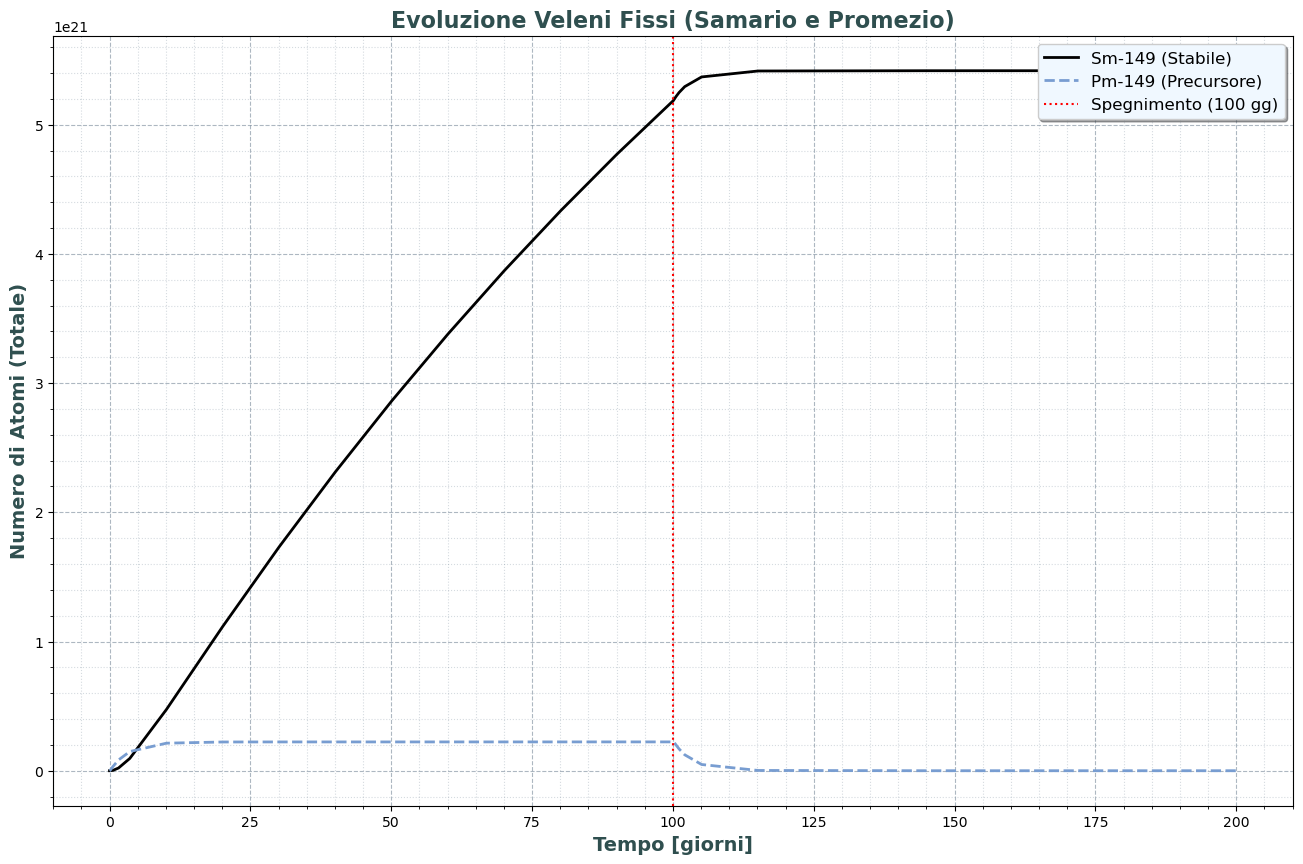

In [2]:
import openmc.deplete
import matplotlib.pyplot as plt
import numpy as np

# 1. Caricamento risultati ed estrazione temporale
results = openmc.deplete.Results("depletion_results.h5")
time_sec, _ = results.get_keff()
days = time_sec / (24 * 3600)

# Inizializzazione array
samarium_tot = np.zeros_like(days)
promethium_tot = np.zeros_like(days)

# 2. Estrazione dinamica e somma globale sui materiali depletabili
depletable_mat_ids = list(results[0].volume.keys())

for mat_id in depletable_mat_ids:
    _, sm_atoms = results.get_atoms(mat_id, "Sm149")
    _, pm_atoms = results.get_atoms(mat_id, "Pm149")
    
    samarium_tot += sm_atoms
    promethium_tot += pm_atoms

# 3. Plotting
fig, ax = plt.subplots(figsize=(16, 10))

# Samario e Promezio
ax.plot(days, samarium_tot, label="Sm-149 (Stabile)", color='#000000', linewidth=2)
ax.plot(days, promethium_tot, label="Pm-149 (Precursore)", color='#789DD1', linestyle='--', linewidth=2)
ax.axvline(x=100, color='red', linestyle=':', label="Spegnimento (100 gg)")

# Formattazione
ax.set_title("Evoluzione Veleni Fissi (Samario e Promezio)", fontsize=16, fontweight='bold', color='#2F4F4F')
ax.set_xlabel("Tempo [giorni]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("Numero di Atomi (Totale)", fontsize=14, fontweight='bold', color='#2F4F4F')

# Griglia e ticks
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.show()